# Ambient HUXt Ensemble

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import os
import sys
from sunpy.coordinates.sun import carrington_rotation_number
import datetime
import pandas as pd
import storm_utils.huxt_utils as HU
from storm_utils.config_paths import get_project_paths
from storm_utils.data_processing import process_huxt
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u

paths = get_project_paths()

## Running HUXt

This will take about 4 hours with 2000 ensembles. 

In [112]:
# HUXt setup

start_cr = int(carrington_rotation_number(datetime.datetime(1995, 1, 1))) + 1     # This is as far back Hpo data goes
end_cr = int(carrington_rotation_number(datetime.datetime(2025, 1, 1))) - 1       # stop at last CR of 2024
n_crs = end_cr - start_cr  # Number of CRs to include

seed = 42  # Random seed for ensemble perturbations

Nens = 2000 # Number of required ensemble members

OVERWRITE=True   # Will overwrite previous huxt runs with same run_number if True

huxt_run_id = 1 # ID given to this HUXt run

In [113]:
# Run the ambient huxt for specified CRS
HU.run_multiple_ambient_ensembles(start_cr, n_crs, Nens, huxt_run_id, seed=seed, overwrite=OVERWRITE)

Rotation 1 / 399
CR start time: 1995-01-27 12:00:00.000
Files already exist for CR1892


KeyboardInterrupt: 

In [54]:
# Checking that files have saved properly
cr = 1901

huxt_file = paths['huxt_data_shared'] / f'HUXt{huxt_run_id}' / f'HUXt_rotation_{cr}.parquet'

df = pd.read_parquet(huxt_file)
df.head()

,v_0,v_1,v_2,v_3,v_4,v_5,v_6,v_7,v_8,v_9,...,v_90,v_91,v_92,v_93,v_94,v_95,v_96,v_97,v_98,v_99
1995-09-29 19:00:00,305.305307,356.094376,521.568644,765.460508,747.924794,306.292701,315.086290,309.735035,389.579990,306.857434,...,765.407942,345.637251,309.327757,316.122560,466.811742,734.450310,324.068475,764.267724,764.599694,399.001776
1995-09-29 19:30:00,305.319427,355.578949,519.963927,765.460516,749.407235,306.362594,315.383695,309.866431,390.078934,306.959455,...,765.411293,346.261831,309.240075,316.270994,466.050806,735.447019,323.815473,764.296355,764.623836,398.920625
1995-09-29 19:30:00,305.335713,355.066663,518.367944,765.460523,750.559607,306.434000,315.694762,310.007096,390.549172,307.063701,...,765.414452,346.896645,309.152643,316.419843,465.287741,736.422261,323.564889,764.325070,764.646715,398.827336
1995-09-29 20:00:00,305.354141,354.557502,516.780679,765.460531,751.492061,306.506811,316.020216,310.159093,390.990781,307.170132,...,765.417427,347.541255,309.065456,316.569053,464.522502,737.375033,323.316701,764.353823,764.668349,398.721854
1995-09-29 20:30:00,305.374684,354.051453,515.202110,765.460538,752.275560,306.580914,316.360834,310.325290,391.403966,307.278706,...,765.420226,348.195184,308.978514,316.718576,463.755059,738.304560,323.070889,764.382573,764.688752,398.604174


## Preprocessing

In [55]:
%%time 
additional_cols = ['Hp30', 'velocity gradient', 'omni_flow_speed']
huxt_run_id = 2 

process_huxt(huxt_run_id, additional_cols, chunk_size=50, save_discontinuities=True)

Processing saved HUXt data at /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt2
Appending CRs 1900 -> 1950
Appending CRs 1950 -> 2000
Appending CRs 2000 -> 2050
File saved at /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt2_modified/discontinuities.npy
Deleted /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt2_modified/HUXt_rotation_2022.parquet
Deleted /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt2_modified/HUXt_rotation_1988.parquet
Deleted /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt2_modified/HUXt_rotation_1998.parquet
Deleted /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt2_modified/HUXt_rotation_1931.parquet
Deleted /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt2_modified/HUXt_rotation_1921.parquet
Deleted /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt2_modified/HUXt_rotation_1953.parquet
Deleted /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt

## View Data

File location: /Users/matthewbillcliff/phd_storm_projects/HUXt/data/HUXt/HUXt2_modified/full_df.parquet
Unique indices: True
Data points: 1286


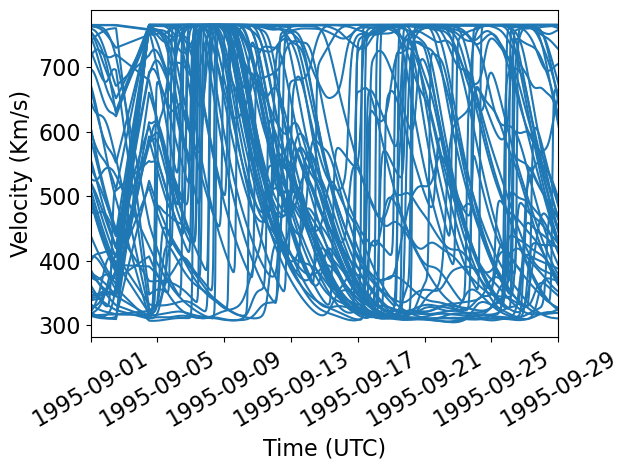

In [107]:
# Check that we have processed correctly
load_path = paths['huxt_data_shared'] / f'HUXt{huxt_run_id}_modified' / 'full_df.parquet'

print('File location:', load_path)
cols_to_load = [f'v_{i}' for i in range(50)]

df = pd.read_parquet(
    load_path, columns=cols_to_load,
)

df = df.loc['1995-09-01':'1995-09-30']

# Check if dataset has unique indices
print('Unique indices:', len(df.index) == len(set(df.index)))

# Columns should read: v_0, v_0_gradient, v_minus_omni_0, v_1, ... , v_99, v_99_gradient, v_minus_omni_99, omni_flow_speed, hp30
print('Data points:', len(df))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.plot(df, color='tab:blue')

# Format x-axis dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# Rotate tick labels
plt.xticks(rotation=30)
plt.xlim(9374, 9402)

plt.xlabel('Time (UTC)')
plt.ylabel('Velocity (Km/s)')

plt.tight_layout()
plt.show()


## OMNI Interpolation

In [27]:
from storm_utils.data_loader import load_omni_data
import numpy as np
import matplotlib.pyplot as plt

omni = load_omni_data()

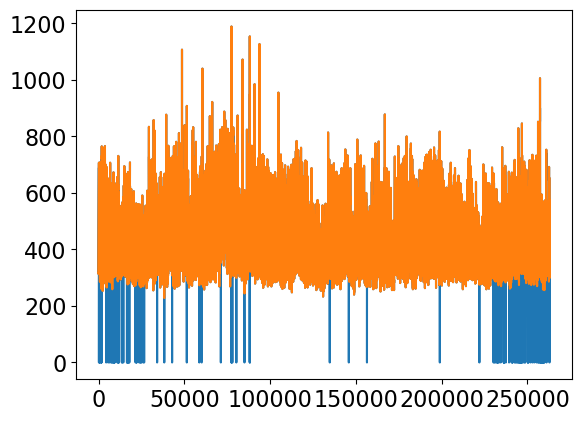

In [32]:
arr = omni['omni_flow_speed']

x = np.arange(len(arr))
non_zero_mask = arr != 0
interp = np.interp(x, x[non_zero_mask], arr[non_zero_mask])

plt.plot(x, arr)
plt.plot(x, interp)
plt.show()